## F-Praktikum: Spectroscopy of supernova SN 1987A v3.0
## Data Analysis

In [14]:
import numpy as np
from astropy.io import fits
# from astropy.visualization import quantity_support
from os.path import join as jp
import matplotlib.pyplot as plt

## 1. Blackbody Fitting to Observed Spectra

The observed spectra closely resemble a blackbody (Planck) spectrum in the optical range. By fitting blackbody functions to the measured data, we can estimate the effective temperature and radius of the photosphere at different epochs.

In [15]:
fits_path = '../fits'

with fits.open(jp(fits_path, 'sn.mt')) as hdul:
    hdul.info()
    hdu = hdul[0]
    header = hdu.header
    data = hdu.data

Filename: ../fits/sn.mt
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     102   (1201, 110)   float32   


### 1.1 Load data and construct wavelength axis

Define a helper function to build the wavelength vector from FITS header parameters (see notebook 01 for details):

In [16]:
def get_wl(header):
    n = header['NAXIS1']
    start = header['CRVAL1']
    delta = header['CDELT1']
    wl = np.arange(start, start + n * delta, delta)
    return wl

wl = get_wl(header)

### 1.2 Define the Planck blackbody function

Define a function to compute the blackbody spectrum. The `astropy` package provides the `BlackBody` class for this purpose:

**Parameters:**
- `wl`: wavelength array (Ångström)
- `T`: effective temperature (Kelvin)
- `scale`: amplitude scaling factor (luminosity factor)

In [17]:
from astropy.modeling.models import BlackBody
import astropy.units as u

def Planck(wl, T, scale=1.0):
    norm = scale * 1.0e-07 * (u.erg / (u.AA * u.s * u.sr * u.cm**2))
    # this is the normalisation of the Planck spectrum we will work with!
    bb = BlackBody(temperature=T * u.K, scale=norm)
    flux = bb(wl * u.AA) # astropy must be aware of units!
    return flux.value # but we will just work with numerical values

### 1.3 Compare blackbody model to observed spectrum

Overlay the Planck function on the observed spectrum for day 5. We test two different temperature/scale combinations to see how they affect the fit quality:

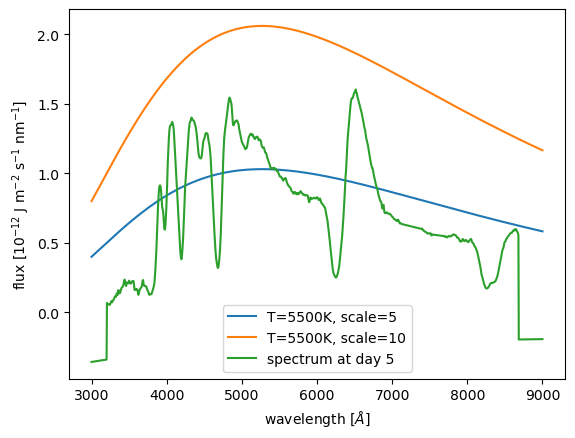

In [18]:
fig, ax = plt.subplots()
ax.plot(wl, Planck(wl, 5500, 5), label='T=5500K, scale=5')
ax.plot(wl, Planck(wl, 5500, 10), label='T=5500K, scale=10')
ax.plot(wl, data[5], label='spectrum at day 5')
ax.set_xlabel(r"wavelength [$\AA$]")
ax.set_ylabel(r"flux [10$^{-12}$ J m$^{-2}$ s$^{-1}$ nm$^{-1}$]")
ax.legend()

### 1.4 Manual fitting exercise

Now you have all the tools needed to fit Planck spectra to the measured SN 1987A data!

**Fitting procedure:**
- Plot the observed spectrum for a selected day
- Overlay Planck curves with different temperatures and scales
- Adjust both `T` and `scale` to find the best match to the continuum shape and brightness
- Record the best-fit parameters and estimate their uncertainties (e.g., ±100 K for temperature)

**Note on fitting methods:** Python has many automatic fitting tools available. You are free to explore them if you have experience with minimization algorithms. However, for this exercise, manual iteration is recommended as it builds physical intuition about the data.

## 2. Measurement of Absorption Line Shifts

As the supernova envelope expands, absorption lines are Doppler-shifted to longer wavelengths. By measuring the shift of strong absorption lines across multiple epochs, we can determine the expansion velocity and ejecta structure.

### 2.1 Measure H-alpha absorption line displacement

Let's examine the Hydrogen-alpha line (rest wavelength 6562 Å) as an example. We'll overlay the rest wavelength as a reference line to visualize the Doppler shift:

Text(0, 0.5, 'flux [10$^{-12}$ J m$^{-2}$ s$^{-1}$ nm$^{-1}$]')

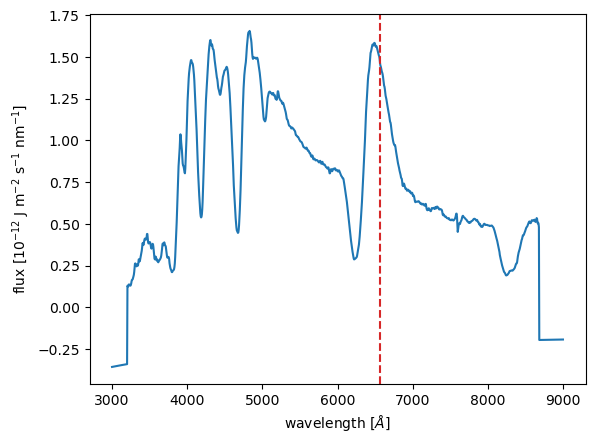

In [19]:
# Depending on your environment, you may get an interactive plotting window enabling one of the following:
# %matplotlib widget
# %matlotlib qt

day = 5

H_alpha = 6562 # AA

lines = [H_alpha,] # you can have more than one

fig, ax = plt.subplots()
ax.plot(wl, data[day-1])
for line in lines:
    ax.axvline(line, linestyle='--', color='tab:red')
ax.set_xlabel(r"wavelength [$\AA$]")
ax.set_ylabel(r"flux [10$^{-12}$ J m$^{-2}$ s$^{-1}$ nm$^{-1}$]")
# ax.set_xlim(4500, 7000) # maybe zooming around the line of interest can help!

### 2.2 P-Cygni profile and next steps

The absorption feature shown above is characteristic of a **P-Cygni profile**, which forms when a stellar wind or expanding envelope produces both absorption (from material moving toward us) and emission (from material receding from us).

**Next steps for your analysis:**
- Measure the wavelength of the line minimum to determine expansion velocity using the Doppler formula
- Repeat this measurement for Na I, Ba II, and Fe II lines to probe different ejecta layers
- Track how line velocities change across the specified observation days (2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100)
- Discuss the implications for ejecta stratification and composition